In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
#import japanize_matplotlib
import seaborn as sns
import numpy as np

# 日本語フォントの設定（環境に合わせて設定してください）
plt.rcParams["font.family"] = "Yu Gothic"   # Windows
#plt.rcParams['font.family'] = 'sans-serif' # Windowsなど
# plt.rcParams['font.family'] = 'AppleGothic' # Macの場合

# 1. データの読み込み
# 実際のファイル名やパスに合わせて変更してください
df = pd.read_csv('./Database/Benesse/1571.csv', encoding='utf-8-sig')
# ここではダミーとしてdfが読み込まれていると仮定します

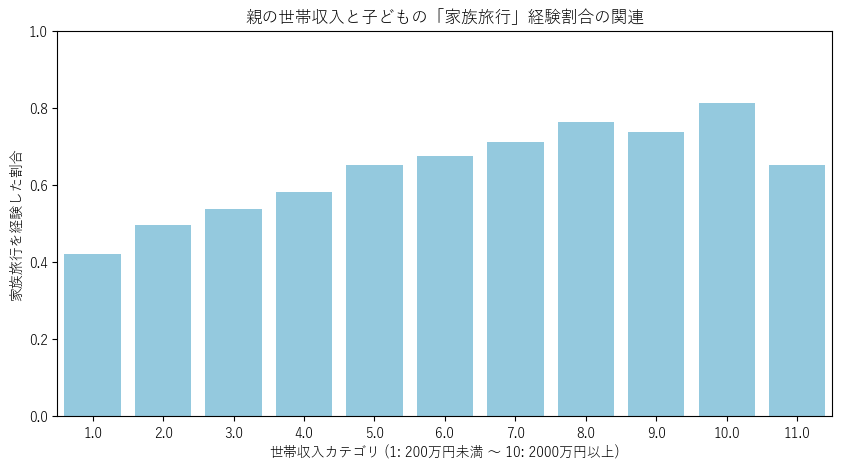

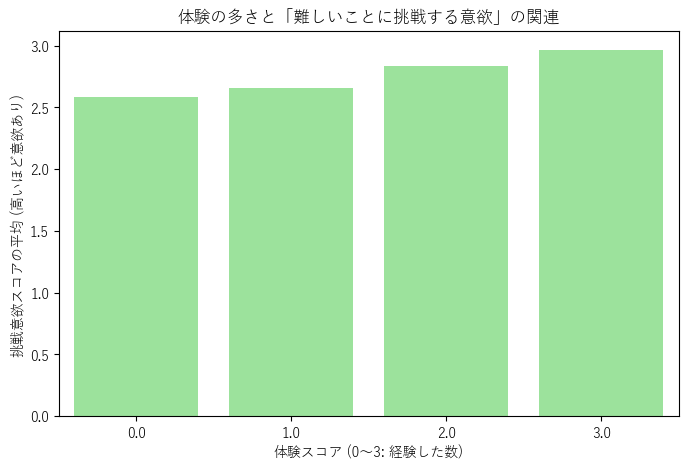

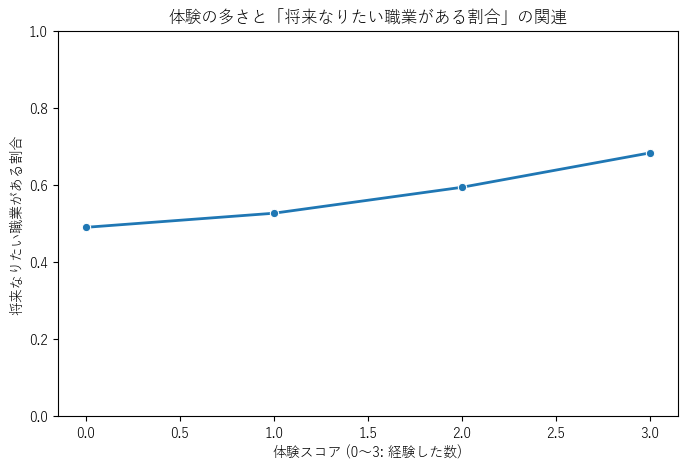

In [2]:
# 2. 分析に必要な変数の抽出（Wave1の例）
columns_to_use = [
    'ds0000000052_w1p', # 昨年の世帯収入（親）: 1(200万未満)〜10(2000万以上)
    'ds0000000268_w1c', # 経験：家族で旅行をする（子）: 0(非選択), 1(選択)
    'ds0000000270_w1c', # 経験：自然の中で思いっきり遊ぶ（子）: 0(非選択), 1(選択)
    'ds0000000271_w1c', # 経験：美術館や博物館に行く（子）: 0(非選択), 1(選択)
    'ds0000000363_w1c', # 性格・特性：難しいことや新しいことにいつも挑戦したい（子）: 1(とても)〜4(まったく)
    'ds0000000210_w1c'  # 将来なりたい職業はあるか（子）: 1(ある), 2(ない)
]

# 分析用データフレームの作成
df_subset = df[columns_to_use].copy()

# 3. 欠損値の処理
# 7777(質問なし), 8888(非該当), 9999(無回答・不明) をNaN(欠損値)に置き換えて除外する[5]
for col in columns_to_use:
    df_subset[col] = df_subset[col].replace(7777, np.nan)
    df_subset[col] = df_subset[col].replace(8888, np.nan)
    df_subset[col] = df_subset[col].replace(9999, np.nan)

df_subset = df_subset.dropna()

# ---------------------------------------------------------
# 分析①：世帯収入によって「体験」の機会に差があるか？
# ---------------------------------------------------------
# 世帯収入カテゴリごとに、家族旅行の経験(1)の平均（割合）を算出
income_travel = df_subset.groupby('ds0000000052_w1p')['ds0000000268_w1c'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='ds0000000052_w1p', y='ds0000000268_w1c', data=income_travel, color='skyblue')
plt.title('親の世帯収入と子どもの「家族旅行」経験割合の関連')
plt.xlabel('世帯収入カテゴリ (1: 200万円未満 ～ 10: 2000万円以上)')
plt.ylabel('家族旅行を経験した割合')
plt.ylim(0, 1)
plt.show()

# ---------------------------------------------------------
# 分析②：多様な「体験」は子どもの意欲や将来の夢に影響するか？
# ---------------------------------------------------------
# 3つの体験の合計スコアを作成 (0～3点)
df_subset['experience_score'] = df_subset['ds0000000268_w1c'] + \
                                df_subset['ds0000000270_w1c'] + \
                                df_subset['ds0000000271_w1c']

# 挑戦意欲スコアの調整
# 元のデータは「1:とてもあてはまる ～ 4:まったくあてはまらない」なので、
# 数値が大きいほど意欲が高いように反転させる（5 - 現在の値）
df_subset['challenge_spirit'] = 5 - df_subset['ds0000000363_w1c']

# 体験スコア別の「挑戦意欲」の平均を算出
exp_challenge = df_subset.groupby('experience_score')['challenge_spirit'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='experience_score', y='challenge_spirit', data=exp_challenge, color='lightgreen')
plt.title('体験の多さと「難しいことに挑戦する意欲」の関連')
plt.xlabel('体験スコア (0～3: 経験した数)')
plt.ylabel('挑戦意欲スコアの平均 (高いほど意欲あり)')
plt.show()

# 将来なりたい職業のダミー変数化 (1:ある->1, 2:ない->0)
df_subset['has_dream'] = df_subset['ds0000000210_w1c'].apply(lambda x: 1 if x == 1 else 0)

# 体験スコア別の「将来なりたい職業がある割合」を算出
exp_dream = df_subset.groupby('experience_score')['has_dream'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.lineplot(x='experience_score', y='has_dream', data=exp_dream, marker='o', linewidth=2)
plt.title('体験の多さと「将来なりたい職業がある割合」の関連')
plt.xlabel('体験スコア (0～3: 経験した数)')
plt.ylabel('将来なりたい職業がある割合')
plt.ylim(0, 1)
plt.show()